# Газоконденсатное месторождение: комплексный анализ
## Курсовая работа

**Студент:** Каширин Егор Викторович

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.fluid import load_pvt_data
from src.reservoir import Reservoir
from src.pipe import Pipe

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RHO_C = 0.6799
XA = 0.0651
XY = 0.9489
T_FIXED = 310.0

fluid, interp = load_pvt_data('interp_data.csv', RHO_C, XA, XY, T_FIXED)

## 1. PVT-МОДЕЛЬ ГАЗА

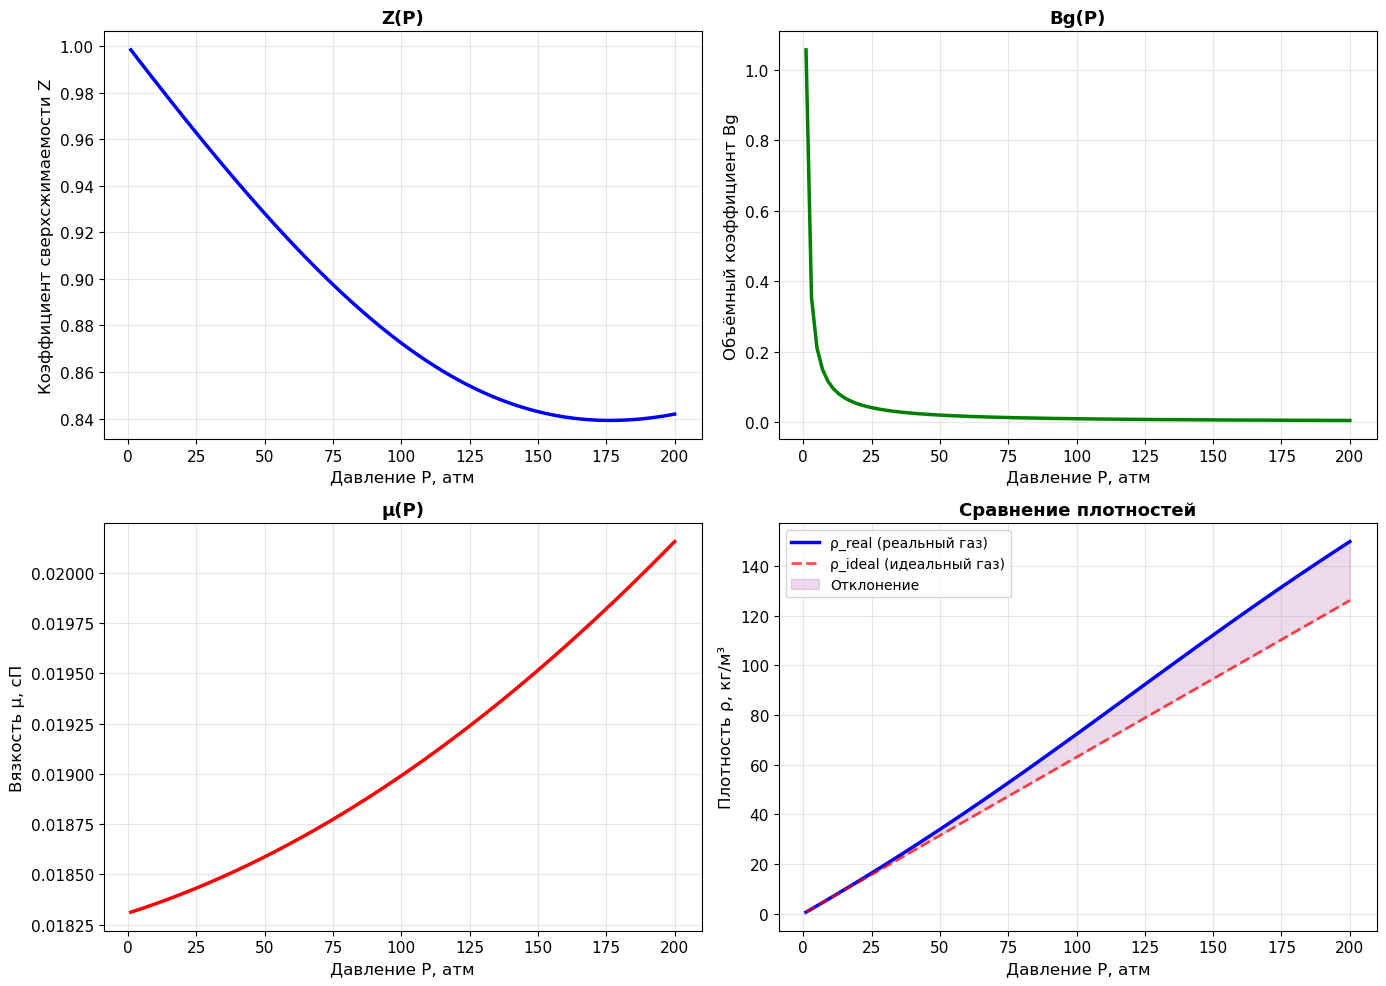

In [2]:
P_range = np.linspace(1, 200, 200)
Z_values = [interp['Z'].predict(p) for p in P_range]
Bg_values = [interp['Bg'].predict(p) for p in P_range]
mu_values = [interp['visc'].predict(p) for p in P_range]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(P_range, Z_values, 'b-', linewidth=2.5)
axes[0, 0].set_xlabel('Давление P, атм', fontsize=12)
axes[0, 0].set_ylabel('Коэффициент сверхсжимаемости Z', fontsize=12)
axes[0, 0].set_title('Z(P)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(P_range, Bg_values, 'g-', linewidth=2.5)
axes[0, 1].set_xlabel('Давление P, атм', fontsize=12)
axes[0, 1].set_ylabel('Объёмный коэффициент Bg', fontsize=12)
axes[0, 1].set_title('Bg(P)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(P_range, mu_values, 'r-', linewidth=2.5)
axes[1, 0].set_xlabel('Давление P, атм', fontsize=12)
axes[1, 0].set_ylabel('Вязкость μ, сП', fontsize=12)
axes[1, 0].set_title('μ(P)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

R_gas = 8.314
M_gas = 0.01604
rho_ideal = [(p * 101325 * M_gas) / (R_gas * T_FIXED) for p in P_range]
rho_real = [rho_ideal[i] / Z_values[i] for i in range(len(P_range))]

axes[1, 1].plot(P_range, rho_real, 'b-', linewidth=2.5, label='ρ_real (реальный газ)')
axes[1, 1].plot(P_range, rho_ideal, 'r--', linewidth=2, alpha=0.7, label='ρ_ideal (идеальный газ)')
axes[1, 1].fill_between(P_range, rho_real, rho_ideal, alpha=0.15, color='purple', label='Отклонение')
axes[1, 1].set_xlabel('Давление P, атм', fontsize=12)
axes[1, 1].set_ylabel('Плотность ρ, кг/м³', fontsize=12)
axes[1, 1].set_title('Сравнение плотностей', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. МОДЕЛЬ ПЛАСТА — КРИВАЯ IPR

Коэффициент продуктивности при P_res = 100.0 атм:
μ(100.0 атм) = 0.018991 сП
C = 65.8964 ст.м³/(сут·атм)


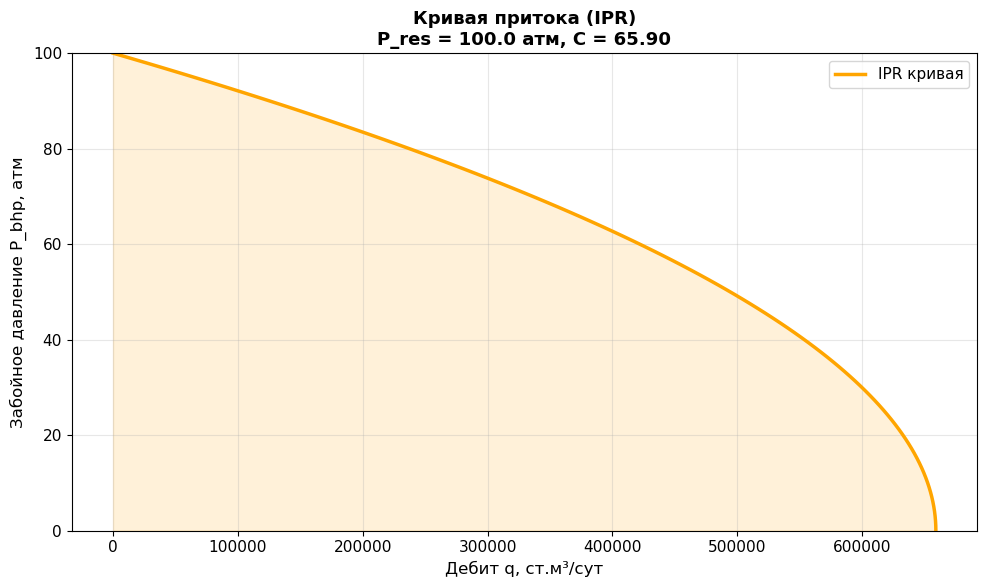

In [3]:
res = Reservoir(k=50.0, h=25.0, re=500.0, rw=0.1, P_res=100.0)

mu_cP = interp['visc'].predict(res.P_res)
C_prod = res.get_productivity_index(mu_cP)

print(f"Коэффициент продуктивности при P_res = {res.P_res} атм:")
print(f"μ({res.P_res} атм) = {mu_cP:.6f} сП")
print(f"C = {C_prod:.4f} ст.м³/(сут·атм)")

P_bhp_range = np.linspace(100, 0, 100)
q_ipr = [res.get_ipr_square(p, C_prod) for p in P_bhp_range]

plt.figure(figsize=(10, 6))
plt.plot(q_ipr, P_bhp_range, color='orange', linewidth=2.5, label='IPR кривая')
plt.fill_between(q_ipr, P_bhp_range, alpha=0.15, color='orange')

plt.xlabel('Дебит q, ст.м³/сут', fontsize=12)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=12)
plt.title(f'Кривая притока (IPR)\nP_res = {res.P_res} атм, C = {C_prod:.2f}', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.ylim(0, 100)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 3. ГИДРАВЛИКА — КРИВЫЕ VLP И λ(Re)

Рассчитанное рабочее P_man = 25.8059 атм
Суммарный дебит Q = 1814089.47 ст.м³/сут


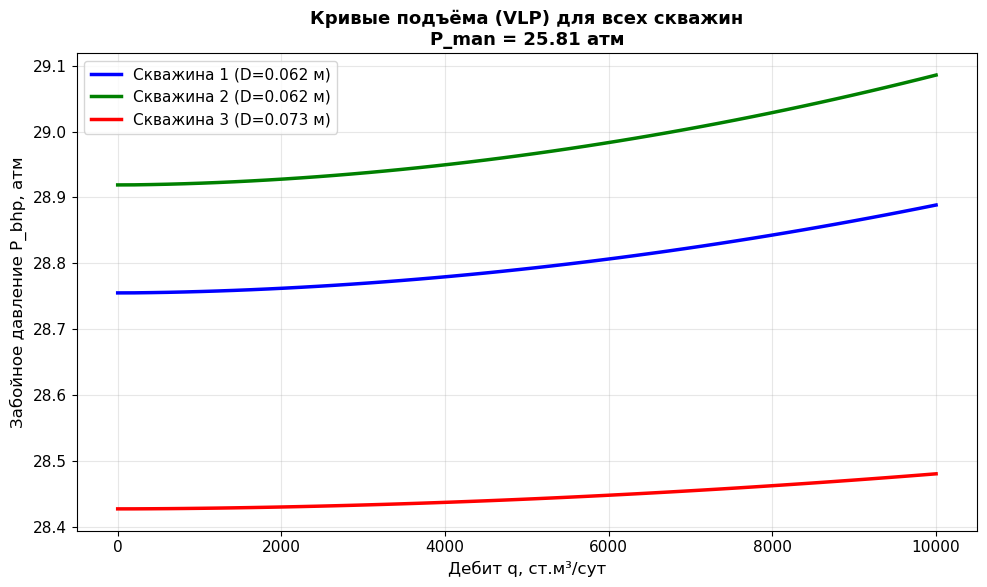

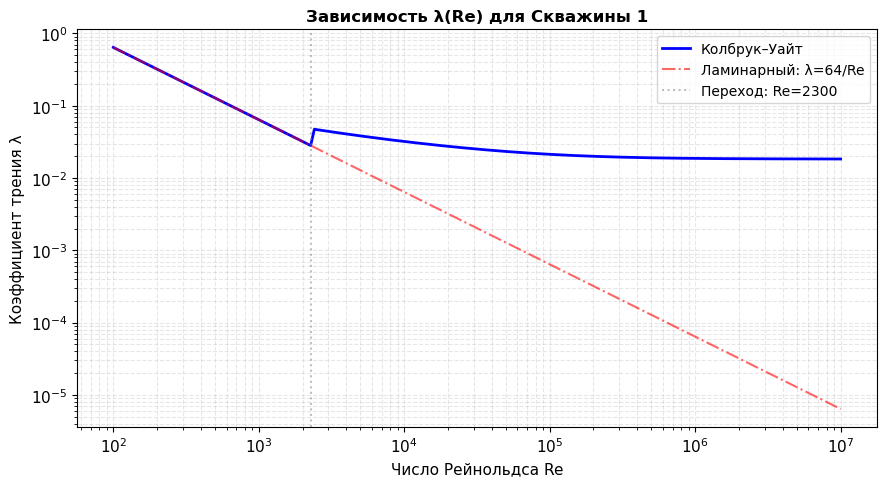

In [4]:
wells_data = {
    'L': [2000, 2500, 1800],
    'D': [0.062, 0.062, 0.073],
    'delta': [0.000046, 0.000046, 0.000046],
    'H': [1800, 1900, 1600],
}

shlyf_L = 5000
shlyf_D = 0.200
shlyf_delta = 0.000046
P_line = 5.0
P_res_init = 100.0

pipes = []
for i in range(3):
    pipe = Pipe(L=wells_data['L'][i], D=wells_data['D'][i], roughness=wells_data['delta'][i], H=wells_data['H'][i])
    pipes.append(pipe)

shlyf = Pipe(L=shlyf_L, D=shlyf_D, roughness=shlyf_delta, H=0.0)

P_man = P_line + 10.0

for _ in range(50):
    q_total = 0.0
    for pipe in pipes:
        dP_est = pipe.calculate_dP(P_man, 1000, interp)
        P_bhp = P_man + dP_est
        q_well = res.get_ipr_square(P_bhp, C_prod)
        q_total += q_well

    dP_shlyf = shlyf.calculate_dP(P_man, q_total, interp)
    P_man_new = P_line + dP_shlyf

    if abs(P_man_new - P_man) < 0.01:
        P_man = P_man_new
        break
    P_man = 0.5 * P_man + 0.5 * P_man_new

print(f"Рассчитанное рабочее P_man = {P_man:.4f} атм")
print(f"Суммарный дебит Q = {q_total:.2f} ст.м³/сут")

plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red']
for i in range(3):
    q_range = np.linspace(0, 10000, 50)
    qs, pbhps = pipes[i].get_vlp(P_man, q_range, interp)
    plt.plot(qs, pbhps, color=colors[i], linewidth=2.5, label=f'Скважина {i+1} (D={wells_data["D"][i]} м)')

plt.xlabel('Дебит q, ст.м³/сут', fontsize=12)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=12)
plt.title(f'Кривые подъёма (VLP) для всех скважин\nP_man = {P_man:.2f} атм', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

D_test = wells_data['D'][0]
delta_test = wells_data['delta'][0]
rel_rough = delta_test / D_test

Re_range = np.logspace(2, 7, 200)
lambda_vals = [pipes[0]._calc_lambda(Re, rel_rough) for Re in Re_range]

plt.figure(figsize=(9, 5))
plt.loglog(Re_range, lambda_vals, 'b-', linewidth=2, label='Колбрук–Уайт')
plt.loglog(Re_range, [64/Re for Re in Re_range], 'r-.', alpha=0.6, label='Ламинарный: λ=64/Re')
plt.axvline(x=2300, color='gray', linestyle=':', alpha=0.5, label='Переход: Re=2300')

plt.xlabel('Число Рейнольдса Re', fontsize=11)
plt.ylabel('Коэффициент трения λ', fontsize=11)
plt.title(f'Зависимость λ(Re) для Скважины 1', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. ДИНАМИКА РАЗРАБОТКИ

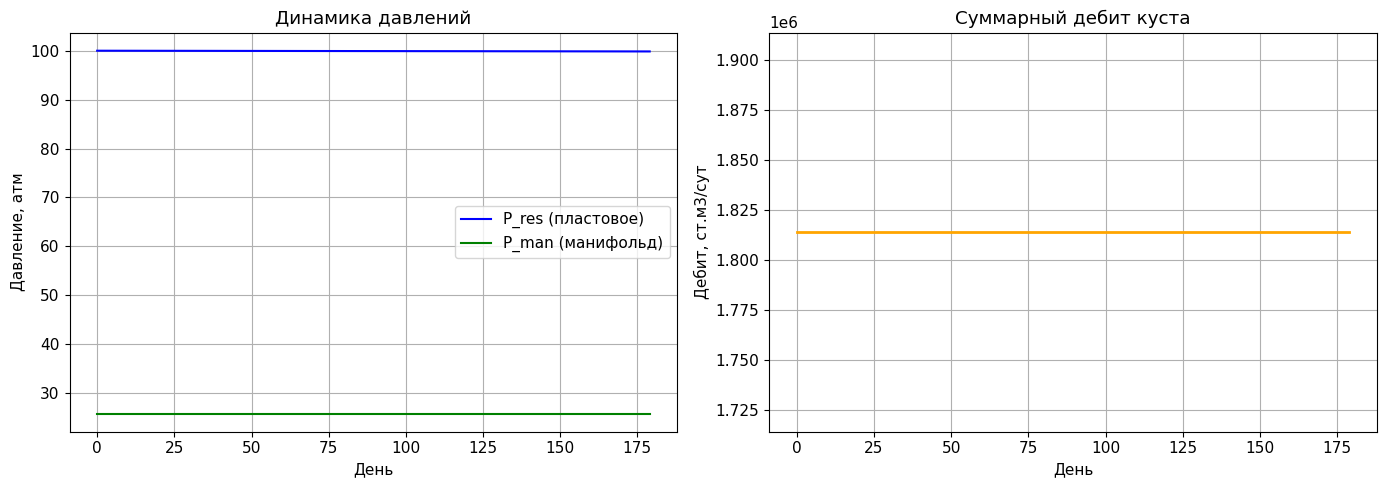

Начальный дебит: 1814089.47
Конечный дебит: 1814089.47


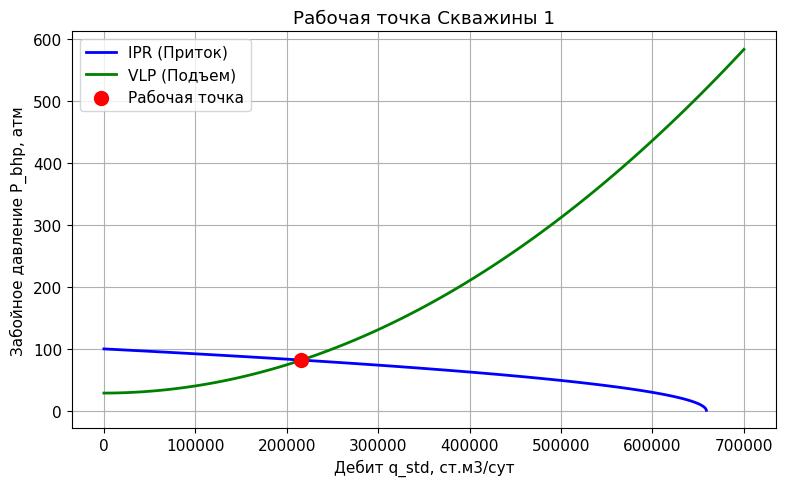

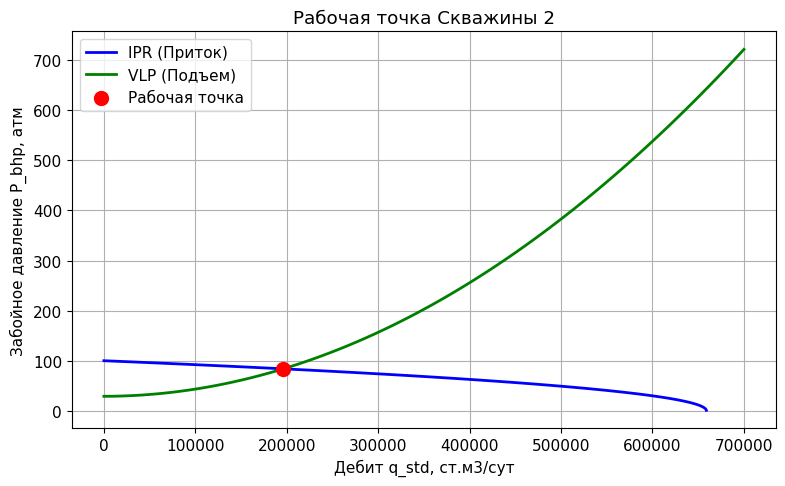

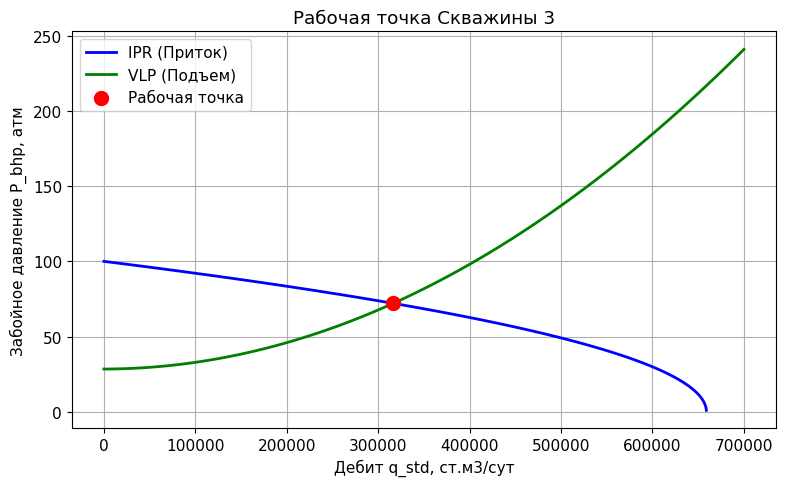

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reservoir import Reservoir
from src.pipe import Pipe

wells_data = {
    'L': [2000, 2500, 1800],
    'D': [0.062, 0.062, 0.073],
    'delta': [0.000046, 0.000046, 0.000046],
    'H': [1800, 1900, 1600],
}

shlyf_L = 5000
shlyf_D = 0.200
shlyf_delta = 0.000046
P_line = 5.0
P_res_init = 100.0

pipes = []
for i in range(3):
    pipe = Pipe(L=wells_data['L'][i], D=wells_data['D'][i], roughness=wells_data['delta'][i], H=wells_data['H'][i])
    pipes.append(pipe)

shlyf = Pipe(L=shlyf_L, D=shlyf_D, roughness=shlyf_delta, H=0.0)

def get_system_state(P_res_current):
    P_man_iter = P_line + 10.0
    for _ in range(50):
        q_total_iter = 0.0
        for pipe in pipes:
            dP_est = pipe.calculate_dP(P_man_iter, 1000, interp)
            P_bhp_est = P_man_iter + dP_est
            q_well = res.get_ipr_square(P_bhp_est, C_prod)
            q_total_iter += q_well
        
        dP_shlyf = shlyf.calculate_dP(P_man_iter, q_total_iter, interp)
        P_man_new = P_line + dP_shlyf
        
        if abs(P_man_new - P_man_iter) < 0.01:
            P_man_iter = P_man_new
            break
        P_man_iter = 0.5 * P_man_iter + 0.5 * P_man_new
    return P_man_iter, q_total_iter

P_man_start, Q_start = get_system_state(P_res_init)

days = []
p_res_hist = []
p_man_hist = []
q_total_hist = []

P_res_curr = P_res_init
V_res = 2e9 
T_res = 310.0
R_gas = 8.314
M_gas = 0.01604
P_std = 1.0
T_std = 293.15

for day in range(180):
    P_man_curr, Q_curr = get_system_state(P_res_curr)
    
    days.append(day)
    p_res_hist.append(P_res_curr)
    p_man_hist.append(P_man_curr)
    q_total_hist.append(Q_curr)
    
    Z_curr = interp['Z'].predict(P_res_curr)
    
    rho_res = (P_res_curr * 101325 * M_gas) / (Z_curr * R_gas * T_res)
    rho_std = (P_std * 101325 * M_gas) / (R_gas * T_std)
    
    mass_prod = Q_curr * rho_std
    mass_init = rho_res * V_res
    mass_next = mass_init - mass_prod
    
    if mass_next < 0:
        mass_next = 0
        
    rho_next = mass_next / V_res
    
    if rho_next > 0:
        P_res_next = (rho_next * Z_curr * R_gas * T_res) / (M_gas * 101325)
    else:
        P_res_next = 0
        
    P_res_curr = max(P_res_next, P_line)

df_dyn = pd.DataFrame({
    'day': days,
    'p_res': p_res_hist,
    'p_man': p_man_hist,
    'q_total': q_total_hist
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_dyn['day'], df_dyn['p_res'], label='P_res (пластовое)', color='blue')
ax1.plot(df_dyn['day'], df_dyn['p_man'], label='P_man (манифольд)', color='green')
ax1.set_title('Динамика давлений')
ax1.set_xlabel('День')
ax1.set_ylabel('Давление, атм')
ax1.legend()
ax1.grid(True)

ax2.plot(df_dyn['day'], df_dyn['q_total'], color='orange', lw=2)
ax2.set_title('Суммарный дебит куста')
ax2.set_xlabel('День')
ax2.set_ylabel('Дебит, ст.м3/сут')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Начальный дебит: {q_total_hist[0]:.2f}")
print(f"Конечный дебит: {q_total_hist[-1]:.2f}")

def plot_well_operating_point(well_idx, P_res_plot, P_man_plot):
    pipe = pipes[well_idx]
    
    q_arr = np.linspace(1, 700000, 100)
    
    p_bhp_ipr = np.linspace(1, P_res_plot, 100)
    q_ipr = [res.get_ipr_square(p, C_prod) for p in p_bhp_ipr]
    
    vlp_p_bhp = []
    for q in q_arr:
        dP = pipe.calculate_dP(P_man_plot, q, interp)
        vlp_p_bhp.append(P_man_plot + dP)
        
    from scipy.interpolate import interp1d
    from scipy.optimize import brentq
    
    sort_idx = np.argsort(q_ipr)
    q_ipr_sorted = np.array(q_ipr)[sort_idx]
    p_bhp_sorted = np.array(p_bhp_ipr)[sort_idx]
    
    ipr_func = interp1d(q_ipr_sorted, p_bhp_sorted, kind='linear', fill_value="extrapolate")
    vlp_func = interp1d(q_arr, vlp_p_bhp, kind='linear', fill_value="extrapolate")
    
    try:
        q_min = max(1, min(q_ipr_sorted[0], q_arr[0]))
        q_max = min(max(q_ipr_sorted[-1], q_arr[-1]), 700000)
        
        def diff(q):
            return ipr_func(q) - vlp_func(q)
            
        q_intersect = brentq(diff, q_min, q_max)
        p_intersect = ipr_func(q_intersect)
    except:
        diffs = np.abs(ipr_func(q_arr) - vlp_func(q_arr))
        idx = np.argmin(diffs)
        q_intersect = q_arr[idx]
        p_intersect = ipr_func(q_intersect)

    plt.figure(figsize=(8, 5))
    plt.plot(q_ipr_sorted, p_bhp_sorted, label='IPR (Приток)', color='blue', linewidth=2)
    plt.plot(q_arr, vlp_p_bhp, label='VLP (Подъем)', color='green', linewidth=2)
    
    plt.scatter([q_intersect], [p_intersect], color='red', zorder=5, s=100, label='Рабочая точка')
    
    plt.title(f'Рабочая точка Скважины {well_idx+1}')
    plt.xlabel('Дебит q_std, ст.м3/сут')
    plt.ylabel('Забойное давление P_bhp, атм')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

for i in range(3):
    plot_well_operating_point(i, P_res_init, P_man_start)

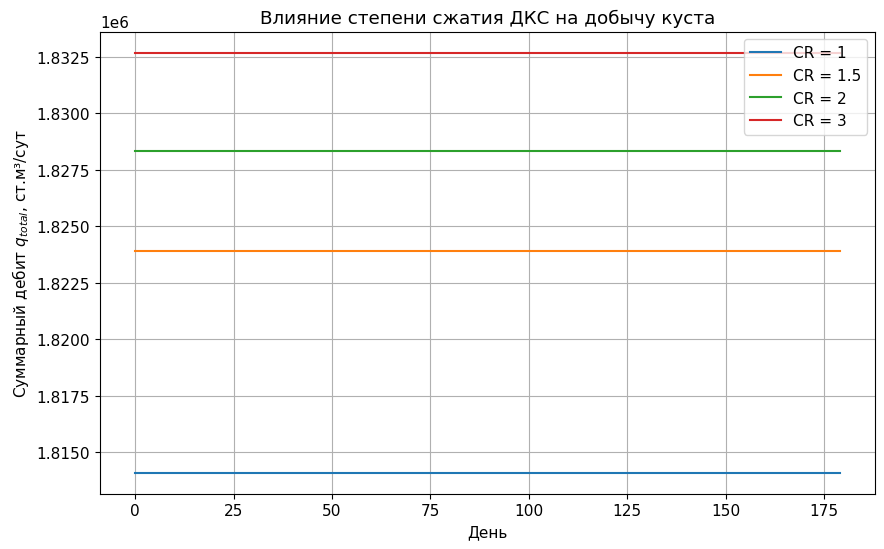

In [6]:

                dP_est = pipe.calculate_dP(P_man_iter, 1000, interp)
                P_bhp_est = P_man_iter + dP_est
                q_well = res.get_ipr_square(P_bhp_est, C_prod)
                q_total_iter += q_well
            
            dP_shlyf = shlyf.calculate_dP(P_man_iter, q_total_iter, interp)
            P_man_new = p_line_current + dP_shlyf
            
            if abs(P_man_new - P_man_iter) < 0.01:
                P_man_iter = P_man_new
                break
            P_man_iter = 0.5 * P_man_iter + 0.5 * P_man_new
        
        days.append(day)
        q_total_hist.append(q_total_iter)
        
        Z_curr = interp['Z'].predict(P_res_curr)
        rho_res = (P_res_curr * 101325 * M_gas) / (Z_curr * R_gas * T_res)
        rho_std = (P_std * 101325 * M_gas) / (R_gas * T_std)
        
        mass_prod = q_total_iter * rho_std
        mass_init = rho_res * V_res
        mass_next = mass_init - mass_prod
        
        if mass_next < 0:
            mass_next = 0
            
        rho_next = mass_next / V_res
        
        if rho_next > 0:
            P_res_next = (rho_next * Z_curr * R_gas * T_res) / (M_gas * 101325)
        else:
            P_res_next = 0
            
        P_res_curr = max(P_res_next, p_line_current)

    plt.plot(days, q_total_hist, label=f'CR = {cr_val}')

plt.title('Влияние степени сжатия ДКС на добычу куста')
plt.xlabel('День')
plt.ylabel('Суммарный дебит $q_{total}$, ст.м³/сут')
plt.legend()
plt.grid(True, which="both", ls="-") 
plt.show()

--- Результаты калибровки ---
Оптимальный коэффициент C: 1712.65
Минимальный RMSE: 438.92 ст.м3/сут
Коэффициент детерминации R2: 0.9991


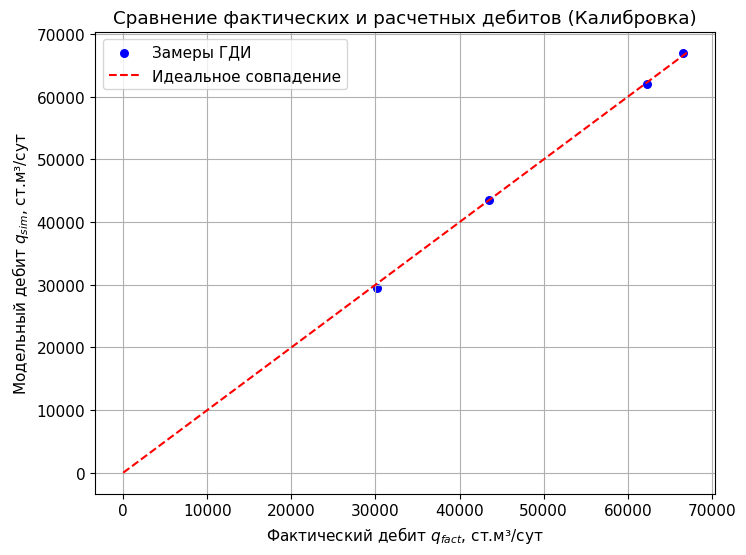

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

df_adapt = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')

q_fact = df_adapt['q'].values
p_res_fact = df_adapt['p_res'].values
p_bhp_fact = df_adapt['p_bhp'].values

def rmse_objective(c_param):
    q_sim = c_param * (p_res_fact**2 - p_bhp_fact**2)
    mse = np.mean((q_sim - q_fact)**2)
    return np.sqrt(mse)

res_opt = minimize(rmse_objective, x0=[1000.0], method='Nelder-Mead')
c_opt = res_opt.x[0]

q_final_sim = c_opt * (p_res_fact**2 - p_bhp_fact**2)
rmse_final = res_opt.fun

ss_res = np.sum((q_fact - q_final_sim)**2)
ss_tot = np.sum((q_fact - np.mean(q_fact))**2)
r2_score = 1 - (ss_res / ss_tot)

print(f"--- Результаты калибровки ---")
print(f"Оптимальный коэффициент C: {c_opt:.2f}")
print(f"Минимальный RMSE: {rmse_final:.2f} ст.м3/сут")
print(f"Коэффициент детерминации R2: {r2_score:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(q_fact, q_final_sim, color='blue', label='Замеры ГДИ', s=30)

max_q = max(q_fact.max(), q_final_sim.max())
plt.plot([0, max_q], [0, max_q], '--', color='red', label='Идеальное совпадение')

plt.title('Сравнение фактических и расчетных дебитов (Калибровка)')
plt.xlabel('Фактический дебит $q_{fact}$, ст.м³/сут')
plt.ylabel('Модельный дебит $q_{sim}$, ст.м³/сут')
plt.legend()
plt.grid(True)
plt.show()